# Introduction

The aim of this project is to estimate the 1-day downside risk of a £100,000 multi-asset portfolio using Value at Risk (VaR) techniques in Python. The portfolio consists of SPY, GLD, TLT, and USO, representing equity, gold, bond, and oil exposure respectively.

Three VaR methods are used: historical simulation, parametric VaR, and Monte Carlo simulation. An Expected Shortfall (ES) extension is also included to provide additional insight into extreme tail losses beyond the VaR threshold.

### Portfolio Setup

In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# Show charts inside the notebook
%matplotlib inline

In [7]:
# Define asset tickers
tickers = ['SPY', 'GLD', 'TLT', 'USO']

# Define portfolio weights
weights = np.array([0.4, 0.2, 0.2, 0.2])

# Define portfolio value in pounds
portfolio_value = 100000

print("Assets:", tickers)
print("Weights:", weights)
print("Portfolio value: £", portfolio_value)

Assets: ['SPY', 'GLD', 'TLT', 'USO']
Weights: [0.4 0.2 0.2 0.2]
Portfolio value: £ 100000


### Data Collection

In [9]:
# Download adjusted closing prices for the last 5 years
price_data = yf.download(tickers, period='5y', auto_adjust=False, progress=False)['Adj Close']

# Drop columns that are completely missing
price_data = price_data.dropna(axis=1, how='all')

# Show the first 5 rows
price_data.head()

Ticker,GLD,SPY,TLT,USO
Date,,,,
2021-03-26,162.240005,369.838593,116.302216,41.529999
2021-03-29,160.309998,369.651764,115.315041,41.919998
2021-03-30,157.570007,368.671051,115.919258,41.169998
2021-03-31,159.960007,370.165497,115.272514,40.529999
2021-04-01,161.979996,374.162903,117.185638,41.840000


In [10]:
print(price_data.columns)

Index(['GLD', 'SPY', 'TLT', 'USO'], dtype='object', name='Ticker')


In [11]:
# Check the shape of the dataset
print("Shape of price data:", price_data.shape)

# Check for missing values
print("\nMissing values in each column:")
print(price_data.isnull().sum())

Shape of price data: (1255, 4)

Missing values in each column:
Ticker
GLD    0
SPY    0
TLT    0
USO    0
dtype: int64


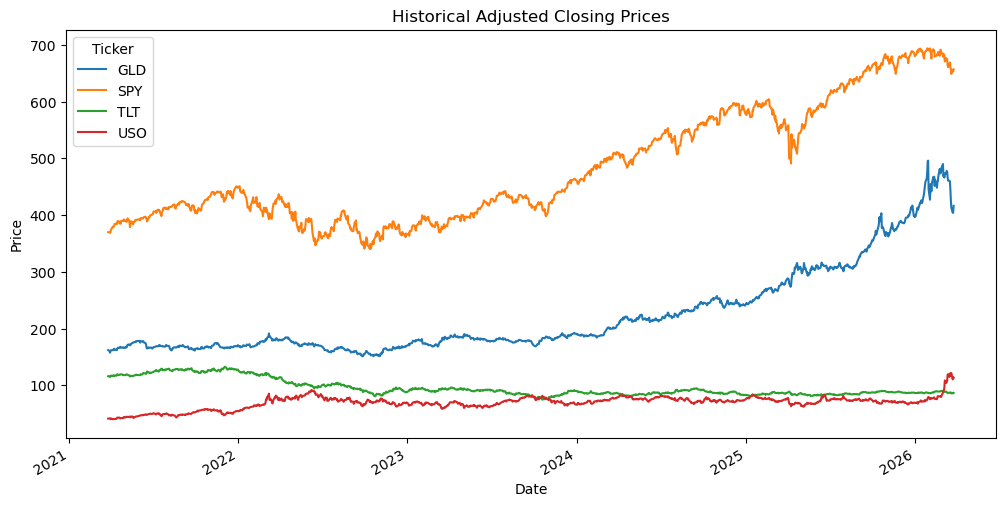

In [12]:
# Plot the historical adjusted closing prices
price_data.plot(figsize=(12, 6))
plt.title("Historical Adjusted Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [13]:
# Reorder columns to match the portfolio weights
price_data = price_data[['SPY', 'GLD', 'TLT', 'USO']]

# Check the new column order
print(price_data.columns)

Index(['SPY', 'GLD', 'TLT', 'USO'], dtype='object', name='Ticker')


### Return Calculation

In [14]:
# Calculate daily percentage returns
returns = price_data.pct_change()

# Drop the first row because it will be missing
returns = returns.dropna()

# Show the first 5 rows
returns.head()

Ticker,SPY,GLD,TLT,USO
Date,,,,
2021-03-29,-0.000505,-0.011896,-0.008488,0.009391
2021-03-30,-0.002653,-0.017092,0.005240,-0.017891
2021-03-31,0.004054,0.015168,-0.005579,-0.015545
2021-04-01,0.010799,0.012628,0.016597,0.032322
2021-04-05,0.014353,-0.000370,-0.004363,-0.037285


In [15]:
# Check the shape of the returns dataset
print("Shape of returns data:", returns.shape)

# Summary statistics
returns.describe()

Shape of returns data: (1254, 4)


Ticker,SPY,GLD,TLT,USO
count,1254.000000,1254.000000,1254.000000,1254.000000
mean,0.000515,0.000813,-0.000183,0.001035
std,0.010699,0.011060,0.010014,0.021569
min,-0.058543,-0.102742,-0.034183,-0.116587
25%,-0.004546,-0.004746,-0.006726,-0.011696
50%,0.000671,0.000738,-0.000110,0.001558
75%,0.006220,0.006659,0.005990,0.013982
max,0.105019,0.063587,0.038474,0.129374


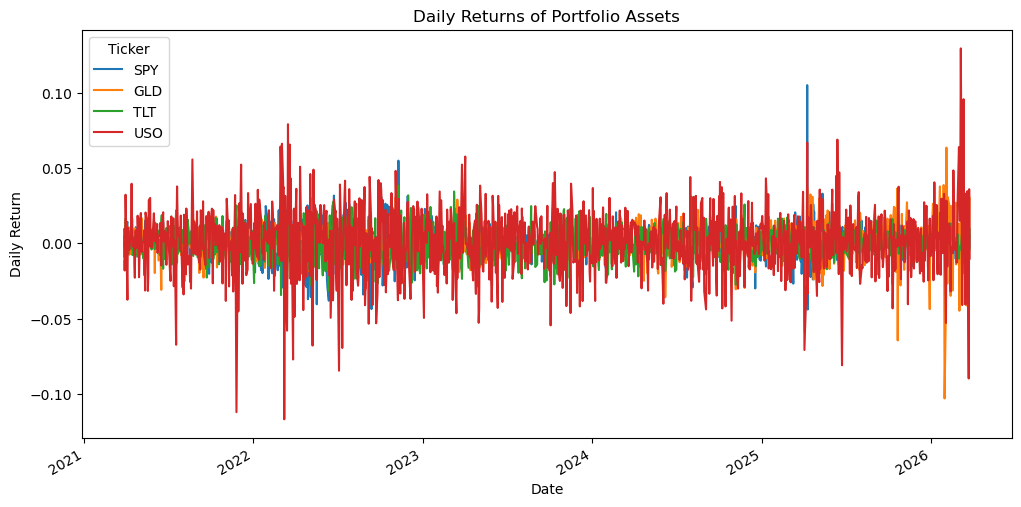

In [16]:
# Plot daily returns
returns.plot(figsize=(12, 6))
plt.title("Daily Returns of Portfolio Assets")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

In [17]:
# Average daily returns
print("Average daily returns:")
print(returns.mean())

# Daily volatility
print("\nDaily volatility:")
print(returns.std())

Average daily returns:
Ticker
SPY    0.000515
GLD    0.000813
TLT   -0.000183
USO    0.001035
dtype: float64

Daily volatility:
Ticker
SPY    0.010699
GLD    0.011060
TLT    0.010014
USO    0.021569
dtype: float64


### Portfolio Return Series

In [18]:
# Calculate portfolio daily returns using the portfolio weights
portfolio_returns = returns.dot(weights)

# Show the first 5 portfolio returns
portfolio_returns.head()

Date
2021-03-29   -0.002401
2021-03-30   -0.007010
2021-03-31    0.000430
2021-04-01    0.016629
2021-04-05   -0.002662
dtype: float64

In [19]:
# Check the type and shape of portfolio returns
print("Type of portfolio_returns:", type(portfolio_returns))
print("Shape of portfolio_returns:", portfolio_returns.shape)

Type of portfolio_returns: <class 'pandas.core.series.Series'>
Shape of portfolio_returns: (1254,)


In [20]:
# Summary statistics for portfolio returns
portfolio_returns.describe()

count    1254.000000
mean        0.000539
std         0.007579
min        -0.037904
25%        -0.003362
50%         0.000534
75%         0.004775
max         0.063971
dtype: float64

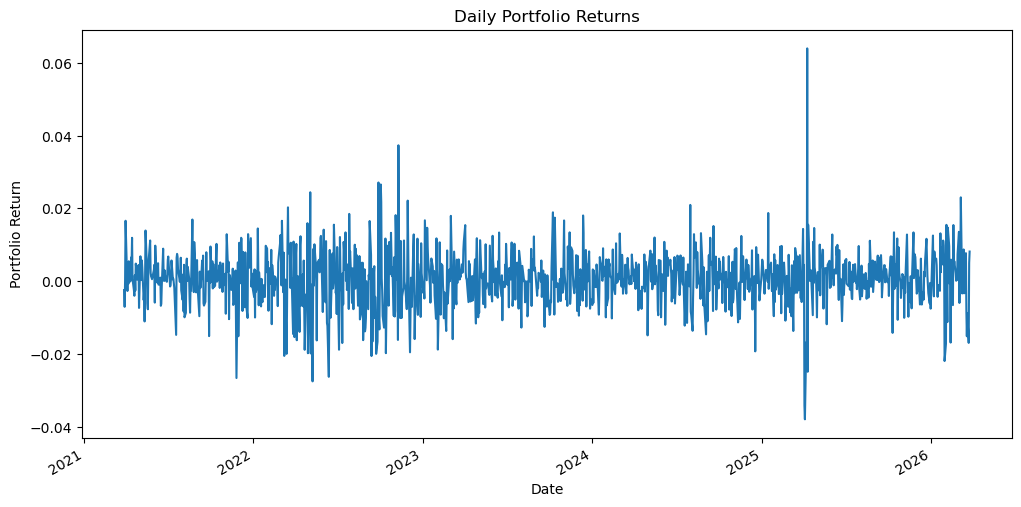

In [21]:
# Plot portfolio returns
portfolio_returns.plot(figsize=(12, 6))
plt.title("Daily Portfolio Returns")
plt.xlabel("Date")
plt.ylabel("Portfolio Return")
plt.show()

In [22]:
# Average portfolio daily return and volatility
print("Average portfolio daily return:", portfolio_returns.mean())
print("Portfolio daily volatility:", portfolio_returns.std())

Average portfolio daily return: 0.0005390604488623308
Portfolio daily volatility: 0.007578589324343166


### Anomaly Analysis

In [23]:
# Find the date of the maximum portfolio return
max_date = portfolio_returns.idxmax()
max_return = portfolio_returns.max()

print("Date of maximum portfolio return:", max_date)
print("Maximum portfolio return:", max_return)

Date of maximum portfolio return: 2025-04-09 00:00:00
Maximum portfolio return: 0.06397113820892822


In [25]:
# Show individual asset returns on the max-return date
print("Asset returns on the max portfolio return date:")
print(returns.loc[max_date])

Asset returns on the max portfolio return date:
Ticker
SPY    0.105019
GLD    0.036991
TLT    0.005886
USO    0.066940
Name: 2025-04-09 00:00:00, dtype: float64


In [26]:
# Calculate each asset's contribution on that date
contribution = returns.loc[max_date] * weights

print("Weighted contributions on the max-return date:")
print(contribution)
print("\nTotal portfolio return from contributions:")
print(contribution.sum())

Weighted contributions on the max-return date:
Ticker
SPY    0.042008
GLD    0.007398
TLT    0.001177
USO    0.013388
Name: 2025-04-09 00:00:00, dtype: float64

Total portfolio return from contributions:
0.06397113820892822


### Interpretation

The largest positive portfolio return occurred on **2025-04-09**, when the portfolio gained approximately **6.40%** in one day. This extreme move was driven mainly by a very large gain in **SPY**, which returned about **10.50%** and contributed approximately **4.20 percentage points** to the overall portfolio return due to its 40% portfolio weight.

Other assets also contributed positively on the same day. **USO** returned about **6.69%**, contributing roughly **1.34 percentage points**, while **GLD** returned about **3.70%** and contributed around **0.74 percentage points**. **TLT** made a smaller positive contribution of approximately **0.12 percentage points** from a return of about **0.59%**.

This shows that the extreme portfolio gain was not caused by diversification reducing volatility, but rather by several assets moving strongly in the same positive direction at once. In particular, the combination of a large SPY move and positive contributions from all other assets produced the unusually high one-day portfolio return.

### Historical Simulation VaR

In [27]:
# Calculate 95% and 99% historical VaR in return terms
var_95_return = -np.percentile(portfolio_returns, 5)
var_99_return = -np.percentile(portfolio_returns, 1)

print("95% Historical VaR (return):", var_95_return)
print("99% Historical VaR (return):", var_99_return)

95% Historical VaR (return): 0.010996127691801406
99% Historical VaR (return): 0.019746586099996837


In [28]:
# Convert VaR from return terms to pound terms
var_95_pounds = portfolio_value * var_95_return
var_99_pounds = portfolio_value * var_99_return

print("95% Historical VaR (£):", var_95_pounds)
print("99% Historical VaR (£):", var_99_pounds)

95% Historical VaR (£): 1099.6127691801405
99% Historical VaR (£): 1974.6586099996837


In [29]:
print(f"At the 95% confidence level, the portfolio is not expected to lose more than £{var_95_pounds:.2f} in one day.")
print(f"At the 99% confidence level, the portfolio is not expected to lose more than £{var_99_pounds:.2f} in one day.")

At the 95% confidence level, the portfolio is not expected to lose more than £1099.61 in one day.
At the 99% confidence level, the portfolio is not expected to lose more than £1974.66 in one day.


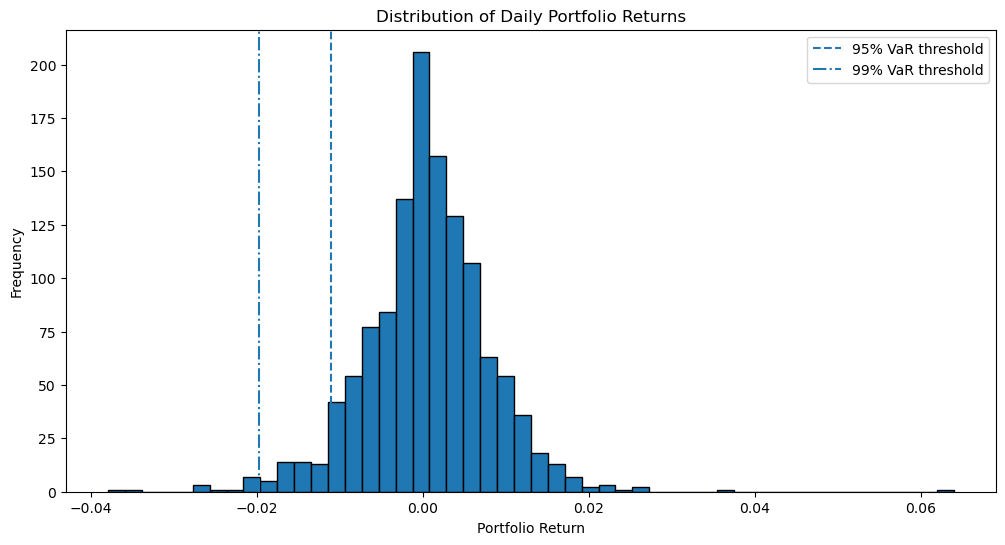

In [31]:
# Plot histogram of portfolio returns
plt.figure(figsize=(12, 6))
plt.hist(portfolio_returns, bins=50, edgecolor='black')

# Add VaR lines
plt.axvline(-var_95_return, linestyle='--', label='95% VaR threshold')
plt.axvline(-var_99_return, linestyle='-.', label='99% VaR threshold')

plt.title("Distribution of Daily Portfolio Returns")
plt.xlabel("Portfolio Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Parametric VaR

In [32]:
from scipy.stats import norm

In [33]:
# Portfolio mean and standard deviation
mu = portfolio_returns.mean()
sigma = portfolio_returns.std()

print("Portfolio mean:", mu)
print("Portfolio standard deviation:", sigma)

Portfolio mean: 0.0005390604488623308
Portfolio standard deviation: 0.007578589324343166


In [34]:
# Z-scores for left-tail confidence levels
z_95 = norm.ppf(0.05)
z_99 = norm.ppf(0.01)

print("95% z-score:", z_95)
print("99% z-score:", z_99)

95% z-score: -1.6448536269514729
99% z-score: -2.3263478740408408


In [35]:
# Parametric VaR in return terms
param_var_95_return = -(mu + z_95 * sigma)
param_var_99_return = -(mu + z_99 * sigma)

print("95% Parametric VaR (return):", param_var_95_return)
print("99% Parametric VaR (return):", param_var_99_return)

95% Parametric VaR (return): 0.011926609688459239
99% Parametric VaR (return): 0.017091374714052008


In [37]:
# Convert parametric VaR to pounds
param_var_95_pounds = portfolio_value * param_var_95_return
param_var_99_pounds = portfolio_value * param_var_99_return

print("95% Parametric VaR (£):", param_var_95_pounds)
print("99% Parametric VaR (£):", param_var_99_pounds)

95% Parametric VaR (£): 1192.660968845924
99% Parametric VaR (£): 1709.1374714052008


In [38]:
print(f"At the 95% confidence level, the parametric VaR is £{param_var_95_pounds:.2f} for one day.")
print(f"At the 99% confidence level, the parametric VaR is £{param_var_99_pounds:.2f} for one day.")

At the 95% confidence level, the parametric VaR is £1192.66 for one day.
At the 99% confidence level, the parametric VaR is £1709.14 for one day.


In [39]:
# Compare historical and parametric VaR
print("Historical VaR vs Parametric VaR")
print(f"95% Historical VaR (£): {var_95_pounds:.2f}")
print(f"95% Parametric VaR (£): {param_var_95_pounds:.2f}")
print()
print(f"99% Historical VaR (£): {var_99_pounds:.2f}")
print(f"99% Parametric VaR (£): {param_var_99_pounds:.2f}")

Historical VaR vs Parametric VaR
95% Historical VaR (£): 1099.61
95% Parametric VaR (£): 1192.66

99% Historical VaR (£): 1974.66
99% Parametric VaR (£): 1709.14


In [40]:
# Create a small comparison table
var_comparison = pd.DataFrame({
    'Historical VaR (£)': [var_95_pounds, var_99_pounds],
    'Parametric VaR (£)': [param_var_95_pounds, param_var_99_pounds]
}, index=['95%', '99%'])

var_comparison

,Historical VaR (£),Parametric VaR (£)
95%,1099.612769,1192.660969
99%,1974.658610,1709.137471


### Monte Carlo VaR

In [41]:
# Set number of Monte Carlo simulations
n_simulations = 10000

print("Number of simulations:", n_simulations)

Number of simulations: 10000


In [47]:
np.random.seed(42)
simulated_returns = np.random.normal(mu, sigma, n_simulations)
simulated_returns[:10]

array([ 0.00430345, -0.00050879,  0.00544763,  0.01208148, -0.00123549,
       -0.00123537,  0.01250727,  0.00635513, -0.00301889,  0.0046509 ])

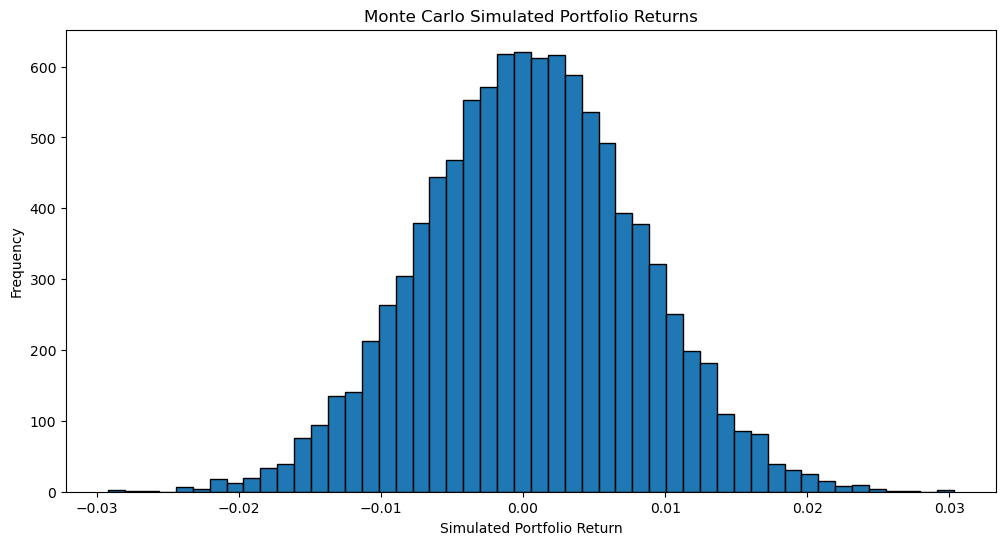

In [48]:
plt.figure(figsize=(12, 6))
plt.hist(simulated_returns, bins=50, edgecolor='black')
plt.title("Monte Carlo Simulated Portfolio Returns")
plt.xlabel("Simulated Portfolio Return")
plt.ylabel("Frequency")
plt.show()

In [49]:
mc_var_95_return = -np.percentile(simulated_returns, 5)
mc_var_99_return = -np.percentile(simulated_returns, 1)

print("95% Monte Carlo VaR (return):", mc_var_95_return)
print("99% Monte Carlo VaR (return):", mc_var_99_return)

95% Monte Carlo VaR (return): 0.012002430315381125
99% Monte Carlo VaR (return): 0.017047380693998092


In [50]:
mc_var_95_pounds = portfolio_value * mc_var_95_return
mc_var_99_pounds = portfolio_value * mc_var_99_return

print("95% Monte Carlo VaR (£):", mc_var_95_pounds)
print("99% Monte Carlo VaR (£):", mc_var_99_pounds)

95% Monte Carlo VaR (£): 1200.2430315381125
99% Monte Carlo VaR (£): 1704.7380693998093


In [51]:
print(f"At the 95% confidence level, the Monte Carlo VaR is £{mc_var_95_pounds:.2f} for one day.")
print(f"At the 99% confidence level, the Monte Carlo VaR is £{mc_var_99_pounds:.2f} for one day.")

At the 95% confidence level, the Monte Carlo VaR is £1200.24 for one day.
At the 99% confidence level, the Monte Carlo VaR is £1704.74 for one day.


### Method Comparison

In [54]:
# Create final VaR comparison table
final_var_comparison = pd.DataFrame({
    'Historical VaR (£)': [var_95_pounds, var_99_pounds],
    'Parametric VaR (£)': [param_var_95_pounds, param_var_99_pounds],
    'Monte Carlo VaR (£)': [mc_var_95_pounds, mc_var_99_pounds]
}, index=['95%', '99%'])

final_var_comparison

,Historical VaR (£),Parametric VaR (£),Monte Carlo VaR (£)
95%,1099.612769,1192.660969,1200.243032
99%,1974.658610,1709.137471,1704.738069


In [55]:
final_var_comparison.round(2)

,Historical VaR (£),Parametric VaR (£),Monte Carlo VaR (£)
95%,1099.61,1192.66,1200.24
99%,1974.66,1709.14,1704.74


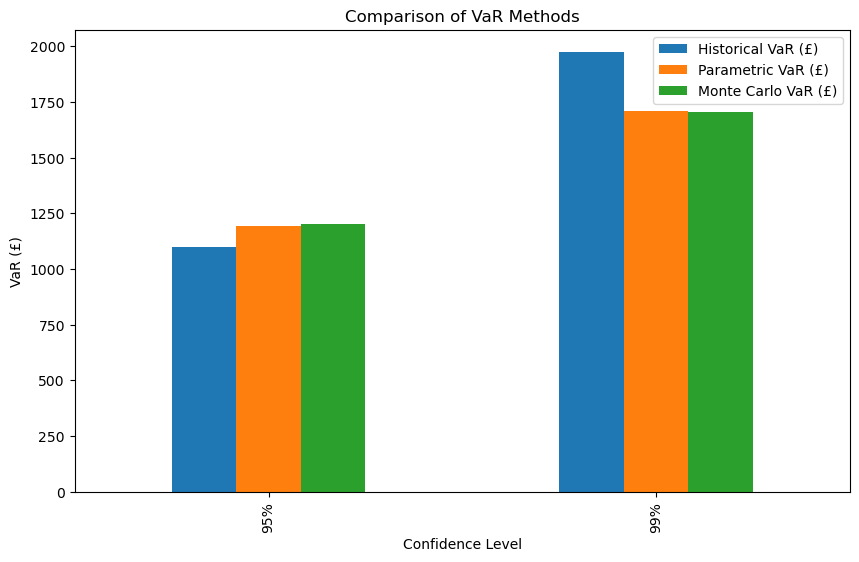

In [57]:
# Bar chart comparing VaR methods
final_var_comparison.plot(kind='bar', figsize=(10, 6))
plt.title("Comparison of VaR Methods")
plt.xlabel("Confidence Level")
plt.ylabel("VaR (£)")
plt.show()

### Historical Simulation ES

In [58]:
# Historical Expected Shortfall (ES) in return terms
es_95_return = -portfolio_returns[portfolio_returns <= np.percentile(portfolio_returns, 5)].mean()
es_99_return = -portfolio_returns[portfolio_returns <= np.percentile(portfolio_returns, 1)].mean()

print("95% Historical Expected Shortfall (return):", es_95_return)
print("99% Historical Expected Shortfall (return):", es_99_return)

95% Historical Expected Shortfall (return): 0.016813002852564884
99% Historical Expected Shortfall (return): 0.0245762107461302


In [59]:
# Convert Expected Shortfall to pounds
es_95_pounds = portfolio_value * es_95_return
es_99_pounds = portfolio_value * es_99_return

print("95% Historical Expected Shortfall (£):", es_95_pounds)
print("99% Historical Expected Shortfall (£):", es_99_pounds)

95% Historical Expected Shortfall (£): 1681.3002852564885
99% Historical Expected Shortfall (£): 2457.62107461302


In [60]:
print(f"At the 95% confidence level, the Historical Expected Shortfall is £{es_95_pounds:.2f} for one day.")
print(f"At the 99% confidence level, the Historical Expected Shortfall is £{es_99_pounds:.2f} for one day.")

At the 95% confidence level, the Historical Expected Shortfall is £1681.30 for one day.
At the 99% confidence level, the Historical Expected Shortfall is £2457.62 for one day.


In [63]:
# Compare Historical VaR and Historical Expected Shortfall
risk_tail_comparison = pd.DataFrame({
    'Historical VaR (£)': [var_95_pounds, var_99_pounds],
    'Historical ES (£)': [es_95_pounds, es_99_pounds]
}, index=['95%', '99%'])

risk_tail_comparison.round(2)

,Historical VaR (£),Historical ES (£)
95%,1099.61,1681.30
99%,1974.66,2457.62


## Expected Shortfall Extension

Expected Shortfall (ES) was added as an extension to complement VaR. While VaR identifies the loss threshold at a given confidence level, ES measures the average loss once returns move beyond that threshold. The results showed that ES was higher than VaR at both the 95% and 99% confidence levels, indicating that tail losses become materially more severe once the VaR cutoff is breached. This highlights the limitation of VaR as a threshold-only measure and shows why ES can provide a more complete view of downside risk.

## Key Findings

- The portfolio’s average daily return was approximately 0.054%, while daily volatility was about 0.758%.
- At the 95% confidence level, Historical VaR was lower than both Parametric and Monte Carlo VaR.
- At the 99% confidence level, Historical VaR was higher than both Parametric and Monte Carlo VaR, suggesting more severe empirical tail losses than a simple normal model captures.
- Parametric VaR and Monte Carlo VaR were very similar because the Monte Carlo simulation was based on a normal distribution using the portfolio mean and standard deviation.
- Historical Expected Shortfall was higher than Historical VaR at both confidence levels, showing that average losses in the tail are materially worse than the VaR threshold alone suggests.
- The results highlight the importance of comparing multiple risk measures and modelling approaches rather than relying on a single estimate.

## Conclusion

This project estimated the 1-day downside risk of a £100,000 multi-asset portfolio consisting of SPY, GLD, TLT, and USO using historical simulation, parametric VaR, and Monte Carlo simulation.

The portfolio return series was constructed by combining daily asset returns using fixed weights of 40% in SPY and 20% each in GLD, TLT, and USO. Over the sample period, the portfolio had an average daily return of approximately 0.054% and daily volatility of about 0.758%.

The 95% VaR estimates ranged from roughly £1,099.61 under the historical method to around £1,200 under the Monte Carlo method. At the 99% level, historical VaR was materially higher than the parametric and Monte Carlo estimates, suggesting that the empirical return distribution contains more severe extreme downside observations than a simple normal-distribution model captures.

The Expected Shortfall extension reinforced this result by showing that average losses beyond the VaR cutoff were significantly larger than the VaR thresholds themselves. Historical Expected Shortfall was approximately £1,681.30 at the 95% confidence level and £2,457.62 at the 99% confidence level, highlighting that tail losses become materially more severe once the VaR threshold is breached.

Overall, the project shows that different risk methods can produce different conclusions depending on how downside risk is measured and what assumptions are imposed on the return distribution. Historical simulation is useful for capturing empirical tail behaviour, while parametric and Monte Carlo methods provide structured model-based estimates. Comparing VaR and Expected Shortfall together gives a more complete view of portfolio downside risk than relying on a single measure alone.